### Task 1

In [1]:
from sympy import integrate, sqrt
from sympy.abc import x

def symbolic_inner_product(f, g, w=1/sqrt(1-x**2)):
    return integrate(w*f*g, (x,-1,1))

phi = []
for j in range(0,6):
    phi.append(x**j)
    for i in range(0,j):
        phi[j] -= symbolic_inner_product(phi[i], x**j) / symbolic_inner_product(phi[i], phi[i]) * phi[i]
    if j>=2:
        phi[-1] *= 2**(j-1)
    display(phi[-1])

1

x

2*x**2 - 1

4*x**3 - 3*x

8*x**4 - 8*x**2 + 1

16*x**5 - 20*x**3 + 5*x

### Task 2

In [40]:
from scipy.integrate import quad
from numpy import *
import matplotlib.pyplot as plt

set_printoptions(precision=8,suppress=True)

n = 5
x_values = linspace(-1,1,1000)
f = lambda x: arctan(x)
correct_y_values = f(x_values)

def create_plot(result, name, override=lambda name: plt.title("Polynomial and error for the "+name)):
    fig, ax1 = plt.subplots()
    first = ax1.plot(x_values, result, 'b', label=name)
    second = ax1.plot(x_values, correct_y_values, 'b:', label="Original function")
    ax1.tick_params('y', colors='b')
    ax2 = ax1.twinx()
    third = ax2.plot(x_values, abs(result - correct_y_values), 'r', label="Error")
    ax2.tick_params('y', colors='r')
    fig.tight_layout()
    override(name)
    lines = first + second + third
    labels = [l.get_label() for l in lines]
    plt.legend(lines, labels, loc=2)
    plt.show()

[ 0.08302157  0.         -0.29228131 -0.          0.9959826  -0.        ]


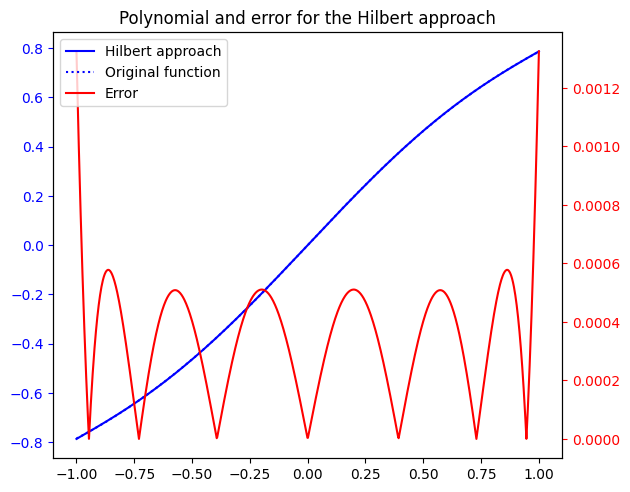

In [41]:
M = empty((n+1,n+1))
for i in range(n+1):
    for j in range(n+1):
        M[i,j] = quad(lambda x: x**(n-i)*x**(n-j), -1, 1)[0]
b = [quad(lambda x: f(x)*x**i, -1, 1)[0] for i in range(n,-1,-1)]
coeff = linalg.solve(M,b)

print(coeff)
create_plot(polyval(coeff, x_values), "Hilbert approach")

[ 0.01054242 -0.         -0.08001405 -0.          0.85619449  0.        ]


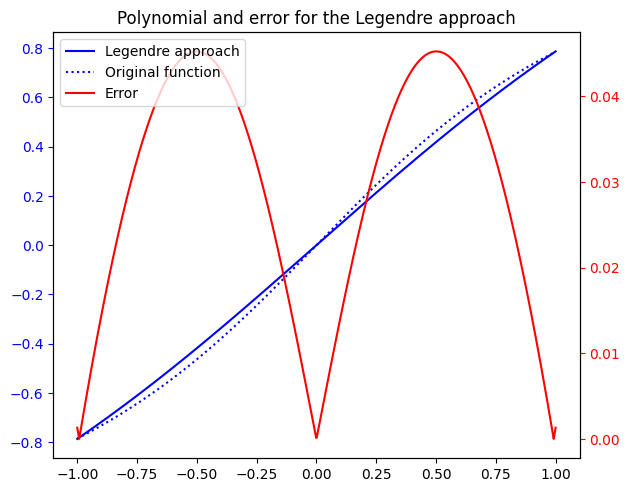

In [42]:
from scipy.special import legendre
    
diagonal = [quad(lambda x: legendre(i)(x)**2, -1, 1)[0] for i in range(n,-1,-1)]
b = [quad(lambda x: f(x)*legendre(i)(x), -1, 1)[0] for i in range(n,-1,-1)]
coeff = array([b[i]/diagonal[i] for i in range(n+1)])

print(coeff)
create_plot(polyval(coeff, x_values), "Legendre approach")

[ 0.00487732  0.         -0.04737854  0.          0.82842712  0.        ]


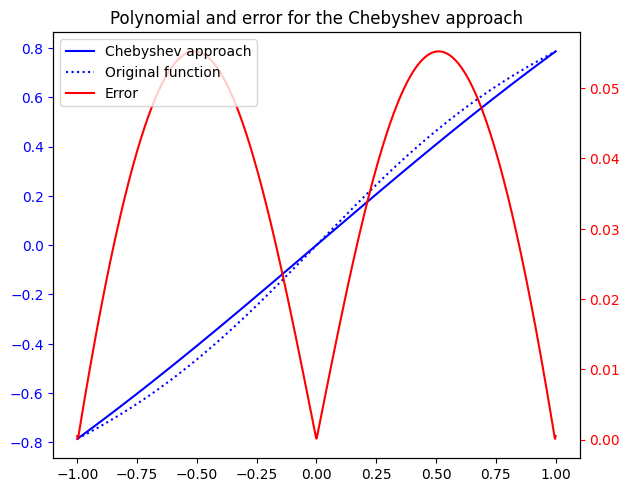

In [43]:
from scipy.special import chebyt
    
diagonal = [quad(lambda x: (1-x**2)**(-1/2)*chebyt(i)(x)**2, -1, 1)[0] for i in range(n,-1,-1)]
b = [quad(lambda x: (1-x**2)**(-1/2)*f(x)*chebyt(i)(x), -1, 1, epsabs=1e-10)[0] for i in range(n,-1,-1)]
coeff = array([b[i]/diagonal[i] for i in range(n+1)])

print(coeff)
create_plot(polyval(coeff, x_values), "Chebyshev approach")

### Task 3

In [13]:
mysimpson_intervals = 12

def mysimpson(f, a, b):
    h = (b-a)/mysimpson_intervals
    result = 0
    for x in linspace(a,b-h,mysimpson_intervals):
        result += f(x) + 4*f(x+h/2) + f(x+h)
    result *= h/6
    return result

### Task 4

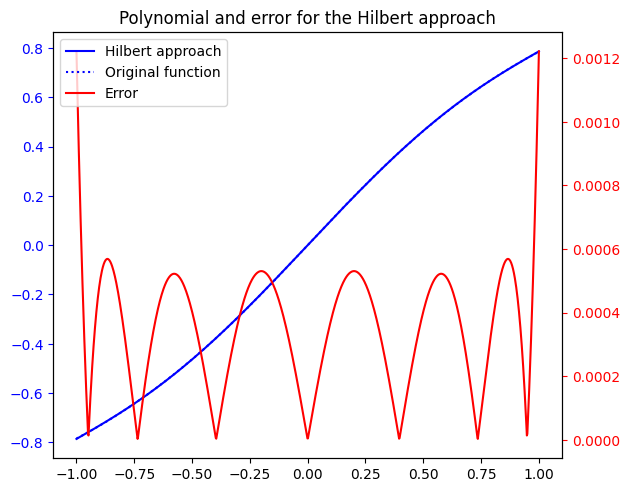

In [14]:
M = empty((n+1,n+1))
for i in range(n+1):
    for j in range(n+1):
        M[i,j] = mysimpson(lambda x: x**(n-i)*x**(n-j), -1, 1)
b = [mysimpson(lambda x: f(x)*x**i, -1, 1) for i in range(n,-1,-1)]
coeff = linalg.solve(M,b)

create_plot(polyval(coeff, x_values), "Hilbert approach")

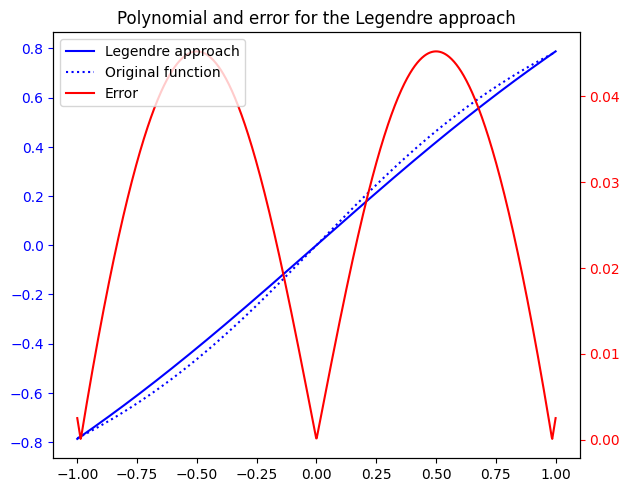

In [15]:
from scipy.special import legendre

def phi(i,x):
    return legendre(i)(x)
    
diagonal = [mysimpson(lambda x: phi(i,x)**2, -1, 1) for i in range(n,-1,-1)]
b = [mysimpson(lambda x: f(x)*phi(i,x), -1, 1) for i in range(n,-1,-1)]
coeff = [b[i]/diagonal[i] for i in range(n+1)]

create_plot(polyval(coeff, x_values), "Legendre approach")